<a href="https://colab.research.google.com/github/tanyasheru23/LangGraph-Learning/blob/main/LangGraph101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 3.5 MB/s eta 0:00:00


In [5]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import random

In [6]:
from google.colab import userdata

OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

# Building First LangGraph Application

LangGraph is a framework for building stateful AI applications using graphs. Unlike traditional chains, LangGraph allows you to define workflows as interconnected nodes that share and update a common state.

In this notebook, we will build a simple AI assistant that:

1. Accepts a user's question
2. Sends the question to an OpenAI model
3. Stores the response in a shared state
4. Returns the generated answer

To create a LangGraph application, we follow five fundamental steps:

1. Define the State Object
2. Initialize the Graph Builder
3. Create Nodes
4. Add Edges
5. Compile the Graph

Let's start by defining the shared state.

## Step 1: Define the State Object

The state acts as the shared memory of the graph. Every node can read information from the state and update it as the workflow progresses.

In this example:

- `question` stores the user's input.
- `answer` stores the response generated by the language model.

Using a structured state helps LangGraph manage information flow between nodes.

In [51]:
class State(BaseModel):
    question: Annotated[str, "user_query"]
    answer: Annotated[str, "agent_response"] = ""

## Step 2: Initialize the Graph Builder

After defining the state, we create a graph builder.

The graph builder is responsible for:

- Managing nodes
- Managing connections between nodes
- Constructing the workflow structure

We provide our `State` class so LangGraph knows what data will be shared throughout the application.

In [52]:
graph_builder = StateGraph(State)

## Step 3: Create a Node

Nodes are the building blocks of a LangGraph workflow.

Each node:

1. Receives the current state
2. Performs some operation
3. Returns an updated state

In this example, our node sends the user's question to an OpenAI model and stores the generated response in the `answer` field.

In [53]:
llm = ChatOpenAI(model="gpt-4o-mini", api_key=OPENAI_API_KEY)

def generate_answer(state: State) -> State:
    response = llm.invoke(
        f"Answer the following question clearly and concisely:\n\n{state.question}"
    )

    return State(
        question=state.question,
        answer=response.content
    )

graph_builder.add_node("generate_answer", generate_answer)

## Step 4: Add Edges

Edges define the execution flow of the graph.

Our workflow is very simple:

START → generate_answer → END

When the graph starts, it executes the `generate_answer` node and then terminates.

More advanced applications may include:

- Conditional routing
- Multiple nodes
- Loops
- Tool calling
- Multi-agent workflows

In [54]:
graph_builder.add_edge(START, "generate_answer")
graph_builder.add_edge("generate_answer", END)

## Step 5: Compile the Graph

Once all nodes and edges have been defined, we compile the graph.

Compilation converts the graph definition into an executable application that can process user inputs and manage state transitions automatically.

We also visualize the graph structure to better understand the workflow.

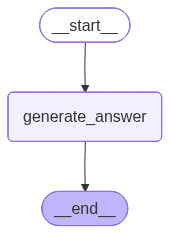

In [55]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

## Running the Graph

Now that the graph has been compiled, we can execute it.

The process is:

1. Create an initial state containing the user's question.
2. Invoke the graph.
3. The graph executes the node.
4. The node updates the state with the generated answer.
5. Return the final result.

This pattern forms the foundation of more advanced LangGraph applications such as agents, RAG systems, and multi-agent workflows.

In [71]:
def chat(user_input, history=None):
    initial_state = State(question=user_input)

    result = graph.invoke(initial_state)

    # print(type(result))
    # print(result)

    return result["answer"]

# gr.ChatInterface(chat, type="messages", chatbot=gr.Chatbot(height=500),).launch()

## Testing the Application

Let's test our LangGraph workflow by providing a question.

The response generated by the OpenAI model will be rendered as Markdown for better readability.

In [73]:
from IPython.display import Markdown, display


answer = chat(input("Enter your query: "))
print()
display(Markdown(answer))

Enter your query: what is diff between langchain and langgraph



LangChain and LangGraph are two different tools in the realm of natural language processing and development.

1. **LangChain**: This is a framework designed to facilitate the development of applications that leverage large language models (LLMs). It provides components for chaining together different processes involving LLMs, such as text generation, summarization, and retrieval. LangChain is particularly useful for building complex applications that require integration of multiple sources of data and model functionalities.

2. **LangGraph**: This is a tool related to visualizing and managing the flow of information in language applications. It allows users to create and manipulate graphs that represent the connections and pathways between different language processing tasks, providing a more intuitive way to design and understand the structure of these applications.

In summary, LangChain focuses on the development framework for LLM applications, while LangGraph emphasizes visualization and management of the processes involved in those applications.